ARTI406 - Machine Learning

# Assignment 1: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

![step1.png](attachment:step1.png)

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [ ]:
#print the path of the dataset
import kagglehub

path = kagglehub.dataset_download("nayakganesh007/nike-sales-uncleaned-dataset")
print("Path:", path)

In [ ]:
# Load Dataset
df = pd.read_csv("/kaggle/input/nike-sales-uncleaned-dataset/Nike_Sales_Uncleaned.csv")

# Display first 5 rows. If you want to display all rows, use df.head(-1)
df.head(-1)

In [ ]:
df.info()

### Check Missing Values

In [ ]:
# Check all values
print(df.isna())

# Check Missing Data

In [ ]:
print(df.isna().sum())

# Check duplicate rows

In [ ]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

### No. of rows and columns

In [ ]:
#number of rows and columns

print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

### Data type of columns

In [ ]:
# viewing the data types of columns
df.dtypes

# Data Before cleaning:

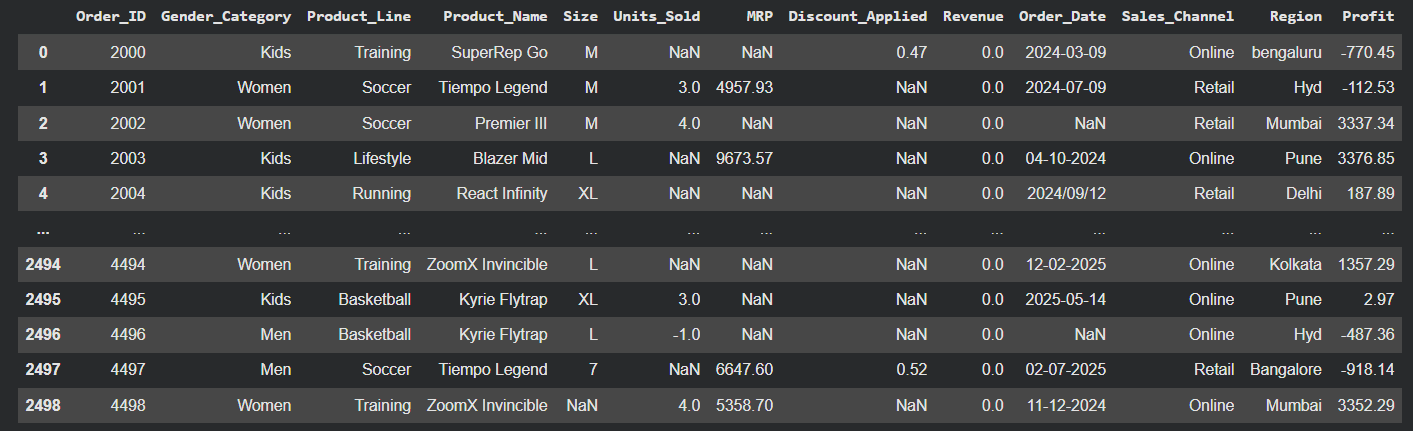

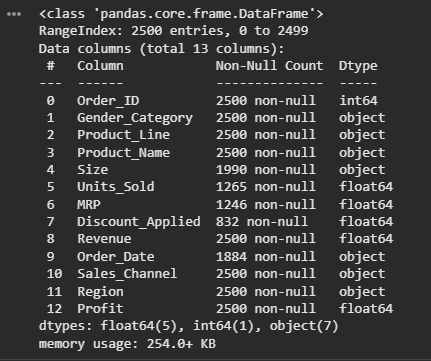

# CLEANING FOR MISSING VALUES...

In [ ]:
# Make a copy before cleaning
df_clean = df.copy()

# Drop rows where critical sales data is missing

# Drop missing Units_Sold and MRP
df_clean = df_clean.dropna(subset=['Units_Sold', 'MRP'])

# Fill missing Discount_Applied with 0 (no discount)
df_clean['Discount_Applied'] = df_clean['Discount_Applied'].fillna(0)

# Fill missing Size with 'Not Specified'
df_clean['Size'] = df_clean['Size'].fillna('Not Specified')

#fix dataframe
df_clean['Order_Date'] = pd.to_datetime(df_clean['Order_Date'], dayfirst=True, errors='coerce')

## Fill missing Order_Date using mode (most common date)
df_clean['Order_Date'] = df_clean['Order_Date'].fillna(df_clean['Order_Date'].mode()[0])

#add features (later for plotting):
df_clean['Year'] = df_clean['Order_Date'].dt.year.astype(int)  # Convert to int, no NaN
df_clean['Month'] = df_clean['Order_Date'].dt.month

# Check remaining missing values
print("Missing values after cleaning:")
print(df_clean.isna().sum())

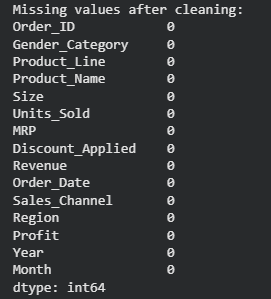

# Data after cleaning:

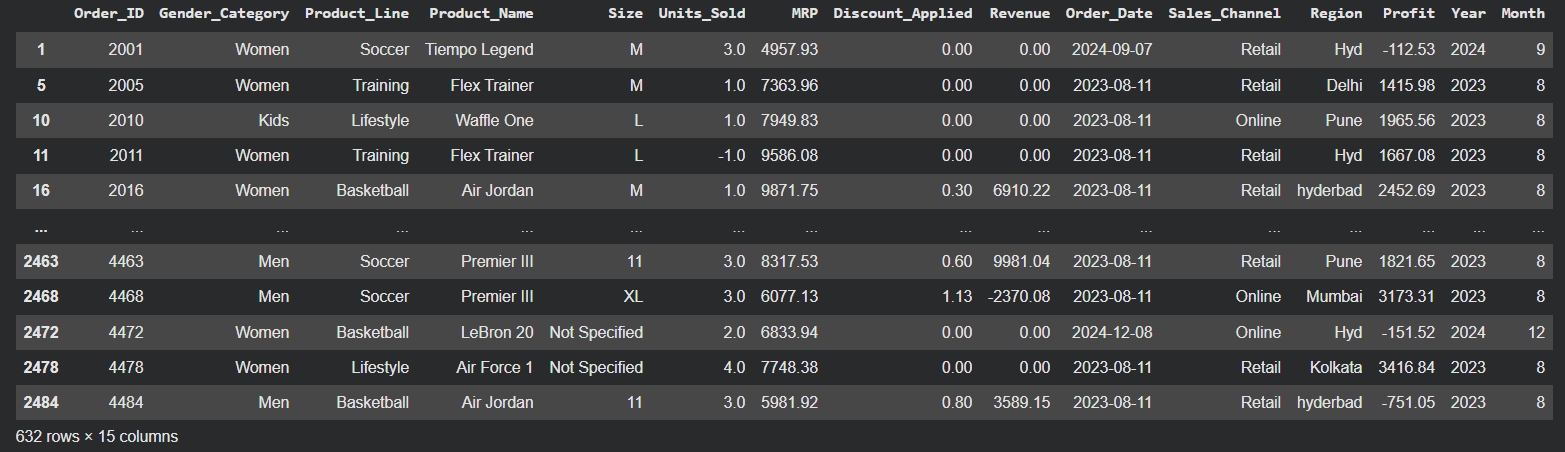

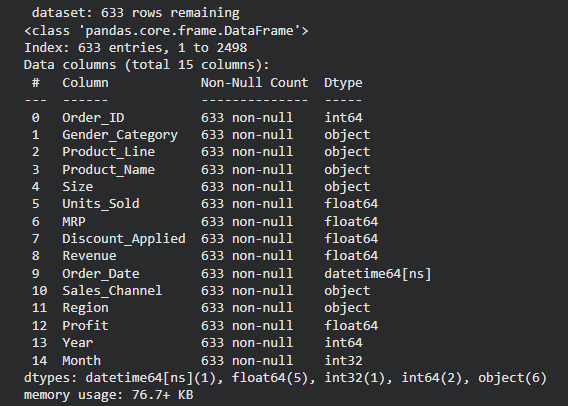

In [ ]:
print(f"\n dataset: {df_clean.shape[0]} rows remaining")
df_clean.info()
df_clean.head(-1)

# CHECK BAD DATA BEFORE CLEANING...

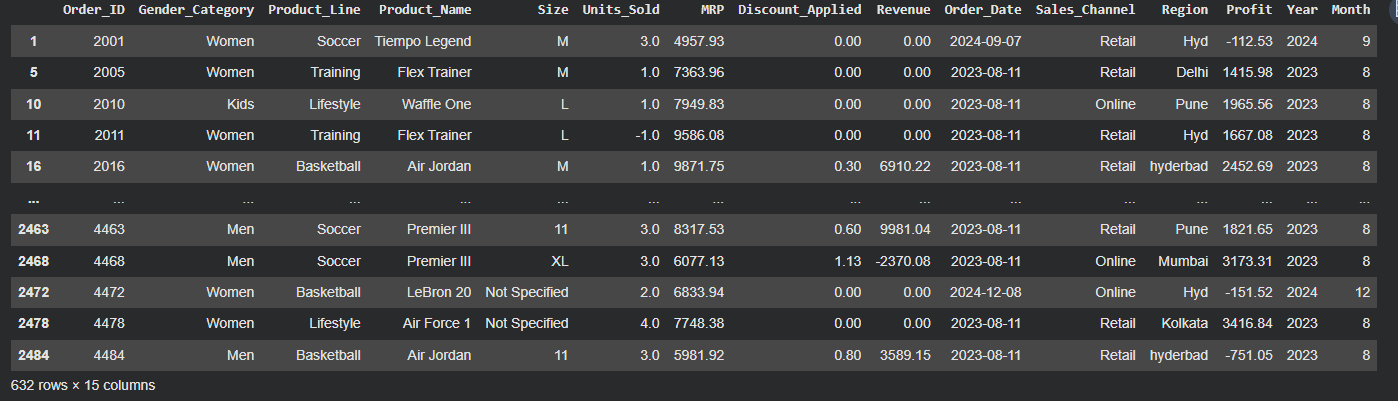

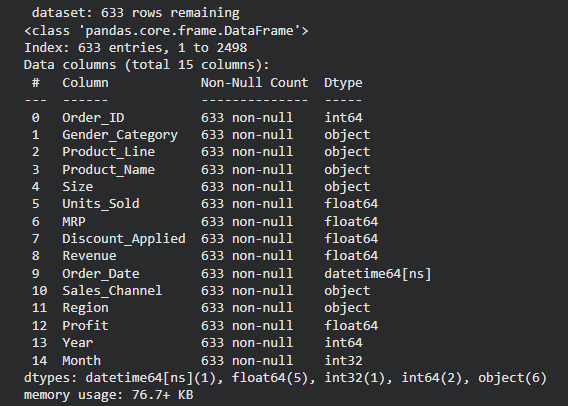

In [ ]:
# Convert Units_Sold to integer
df_clean['Units_Sold'] = df_clean['Units_Sold'].astype(int)

# Check negative and zero Units_Sold
print(f"Rows with negative or zero Units_Sold before: {(df_clean['Units_Sold'] <= 0).sum()}")

# Check discounts > 100%
print(f"Rows with discount >100% before: {(df_clean['Discount_Applied'] > 1.0).sum()}")

# Check negative or zero MRP
print(f"Rows with negative or zero MRP: {(df_clean['MRP'] <= 0).sum()}")

# Check negative revenue
print(f"Rows with negative or zero Revenue: {(df_clean['Revenue'] <= 0).sum()}")

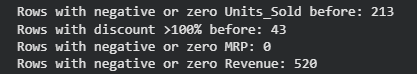

# CLEANING DATA...

In [ ]:
# This removes negative values (Zero units sold means a transaction with no products, represent data entry errors)
df_clean = df_clean[df_clean['Units_Sold'] > 0]


# Remove discounts > 100%
df_clean = df_clean[df_clean['Discount_Applied'] <= 1.0]

# Remove bad Revenue
df_clean = df_clean[df_clean['Revenue'] > 0]

print(f"\n Final clean dataset: {df_clean.shape[0]} rows remaining")


# Data after cleaning

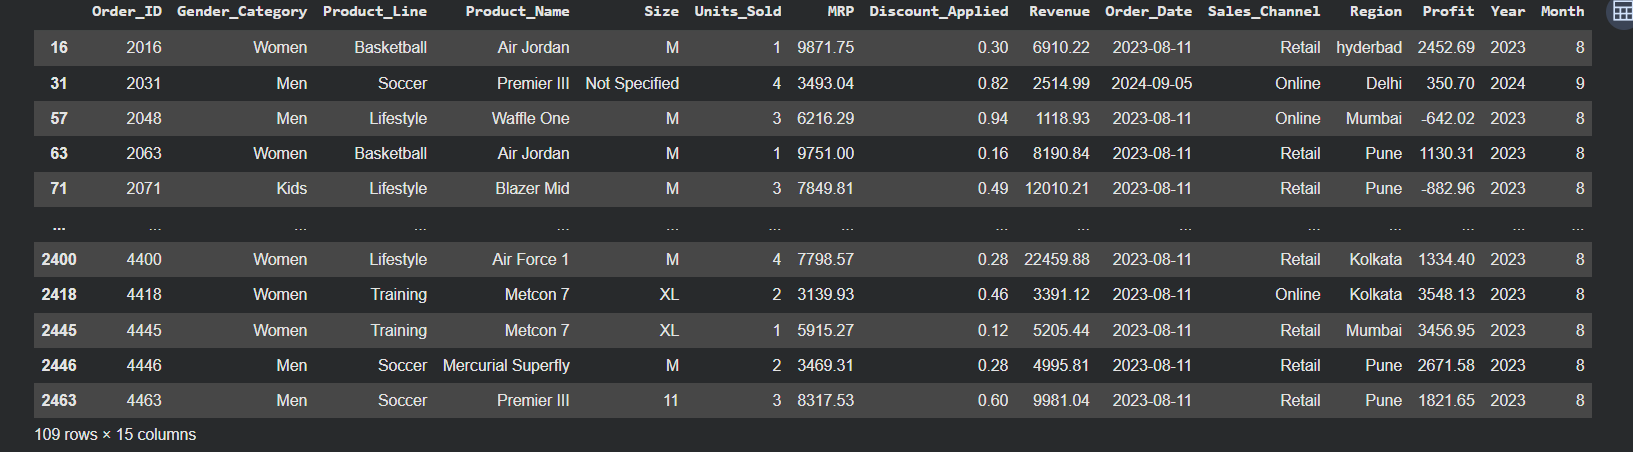

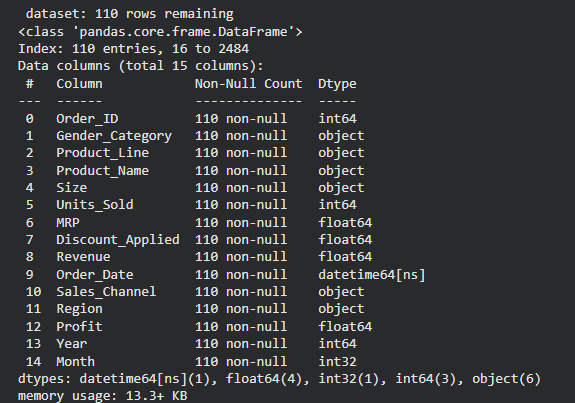

In [ ]:
print(f"\n dataset: {df_clean.shape[0]} rows remaining")
df_clean.info()
df_clean.head(-1)

In [ ]:

df_clean.head(-1)

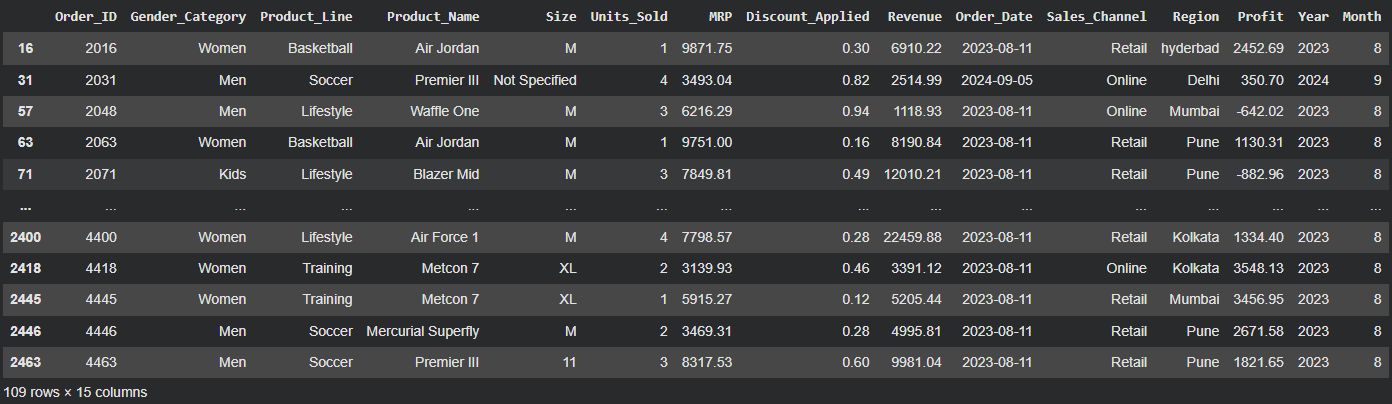

## Fix Typos in regions

In [ ]:
# Typos in regions
df_clean['Region'].unique()

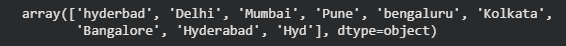

In [ ]:
#Correct region typos
corrections = {
    'bengaluru': 'Bangalore',
    'hyderbadc': 'Hyderabad',
    'hyderbad':'Hyderabad',
     'Hyd':'Hyderabad'
}
df_clean['Region'] = df['Region'].replace(corrections)
df_clean['Region'].unique()


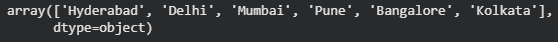

In [ ]:
df_clean.info()


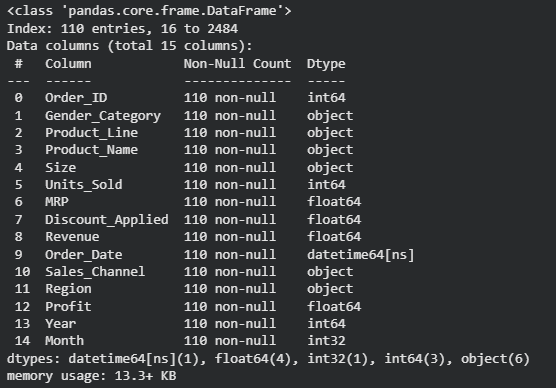

In [ ]:
# Statistical summary
df_clean.describe(include='all')

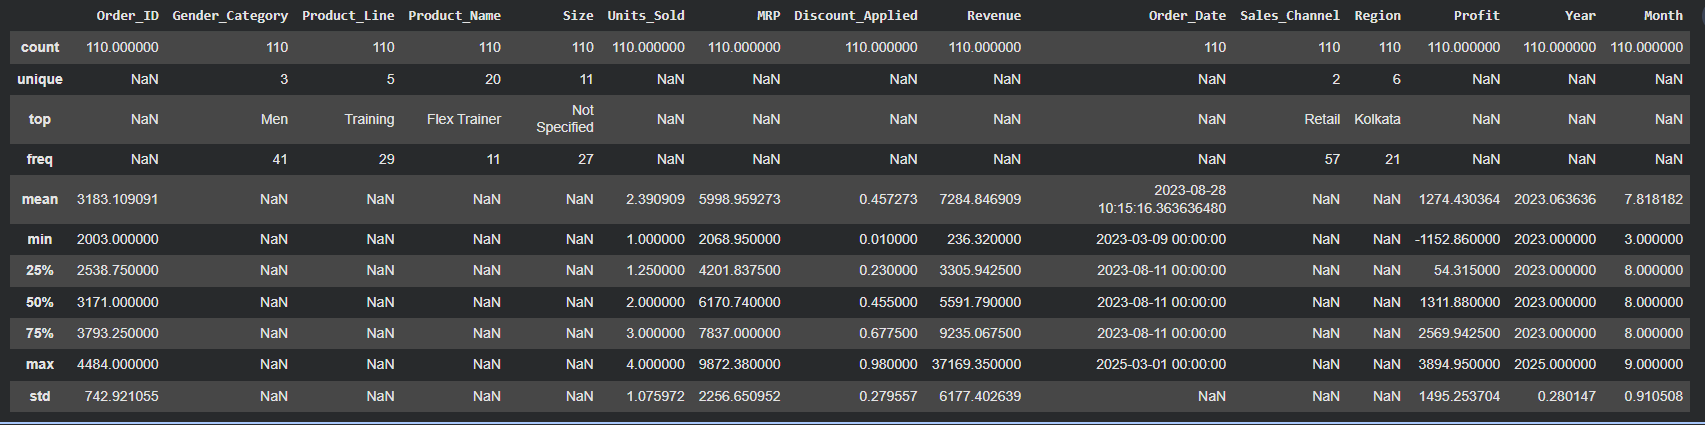

### Descriptive summary Statistics

**Units_Sold**: range from 1 to 4 units per transaction, with mean of 2.4 units. The median is 2 units..

**MRP (Maximum Retail Price)**: from 2069 to 9872, mean of 5999. meaning Products are typically mid range priced.

**Discount_Applied**: discounts vary from 1% to 98%, with mean of 45.7% - meaning average discounts are nearly half the original price.

**Revenue**: transaction values range from 236 to 37169, with mean of 7285. The median 5592 is lower than the mean, indicating a right skewed distribution.

**Profit**: profit ranges from -1153 to 3895, with mean of 1,274. meaning some transactions resulted in a loss.

**Categorical Columns**:
- Gender: Men represent the largest customer segment.
- Product Line: Training most common.
- Top product: Flex Trainer.
- Sales Channel: Retail outperform Online
- Most common region: Kolkata

**Date Range**: The data range from March 2023 to July 2025.


# Univariate Analysis

##Revenue Distribution

In [ ]:
plt.hist(df_clean['Revenue'], bins=20, color='skyblue')
plt.title('Distribution of Revenue per Transaction', fontsize=12, fontweight='bold')
plt.xlabel('Revenue ($)')
plt.ylabel('Number of Transactions')
plt.axvline(df_clean['Revenue'].mean(), color='red', linestyle='--', label=f'Mean: ${df_clean["Revenue"].mean():.0f}')
plt.show()

Most transactions fall in the range of 5000- 10000, with fewer high-value sales above 20000. The distribution is right-skewed, showing normal sales are mid range, not very low or very high

##Units Distribution

In [ ]:
plt.hist(df_clean['Units_Sold'], color='lightgreen')
plt.title('Distribution of Units Sold per Transaction', fontsize=12, fontweight='bold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')

plt.show()

Most transactions have 1-4 units per order, with 2 units being most common. showing customers typically buy 2-3 items per transaction.


##Gender Revenue

In [ ]:
gender_revenue = df_clean.groupby('Gender_Category')['Revenue'].sum()
colors = ['skyblue', 'lightgreen', 'pink']
plt.pie(gender_revenue, labels=gender_revenue.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Revenue Distribution by Gender', fontsize=12, fontweight='bold')
gender_revenue

Men generate the highest revenue at 38.8% , followed closely by Women at 32.7% , and Kids at 28.5% .The distribution is balanced across the three categories

# Bivariate Analysis

##Product Line Revenue

In [ ]:
product_revenue = df_clean.groupby('Product_Line')['Revenue'].sum().sort_values()
product_revenue.plot(kind='barh', color='pink')
plt.title('Total Revenue by Product Line', fontsize=12, fontweight='bold')
plt.xlabel('Total Revenue ($)')
plt.ylabel('Product Line')
product_revenue

Training generates the highest revenue at 211,229, and Running contribute the least at 94,610.
Training products are the top performer

##Discount vs Revenue

In [ ]:
plt.scatter(df_clean['Discount_Applied'] * 100, df_clean['Revenue'],
            alpha=0.6, color='green')
plt.title('Discount Percentage vs Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Discount (%)')
plt.ylabel('Revenue ($)')
plt.grid(True, alpha=0.3)


The scatter plot shows No clear relationship between discount and revenue. discounts alone don't determine sales performance.
heavily discounted transactions generate low revenue, while full priced product get higher revenue.

##Sales Channel

In [ ]:
channel_revenue = df_clean.groupby('Sales_Channel')['Revenue'].sum()
plt.pie(channel_revenue, labels=channel_revenue.index, autopct='%1.1f%%',
        colors=['skyblue','lightgreen'] , startangle=90)
plt.title('Revenue by Sales Channel', fontsize=12, fontweight='bold')
channel_revenue

Online generates slightly higher revenuecompared to Retail.
Nike's sales are well-balanced across digital and physical stores.

##Top Products

In [ ]:
top_products = df_clean.groupby('Product_Name')['Revenue'].sum().nlargest(5)
top_products.plot(kind='bar', color='pink')
plt.title('Top 5 Products by Revenue', fontsize=12, fontweight='bold')
plt.xlabel('Product Name')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45, ha='right')
top_products

Flex Trainer best selling product in revenue, and Zoom Freak contribute the least. indicating clear product performance differences. Training shoes leading the revenue

## Revenue by Region

In [ ]:
region_revenue = df_clean.groupby('Region')['Revenue'].sum().sort_values()
plt.barh(region_revenue.index, region_revenue.values, color='lightgreen')
plt.title('Revenue by Region')
plt.xlabel('Total Revenue ($)')
plt.tight_layout()
plt.show()

Kolkata generates the highest revenue, followed by Hyderabad. Bangalore, Dehli and Pine Almost equall, Lastly Mumbai. Performance varies significantly across cities

# Time-Based Analysis

##Monthly Trend

In [ ]:
monthly_revenue = df_clean.groupby('Month')['Revenue'].sum()
plt.plot(monthly_revenue.index, monthly_revenue.values, marker='o')
plt.title('Monthly Revenue Trend', fontsize=12, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
monthly_revenue

August shows massive revenue spike at 773,238 , while all other months have minimal sales under 16,000. This could indicate a back to school or summer promotion period. The remaining months show very low activity.

##Correlation Matrix

In [ ]:
# Select numeric columns
numeric_cols = ['Units_Sold', 'MRP', 'Discount_Applied', 'Revenue', 'Profit']

# Create correlation matrix
corr_matrix = df_clean[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Insights from correlation matrix:

close to +1 = strong positive relationship
as shown, Revenue and Units_Soldhave a moderate positive relationship. More units sold leads to higher revenue

close to -1 = strong negative relationship
Revenue and Discount_Applied have a moderate negative relationship. Higher discounts result in lower revenue.

close to 0 = no relationship
MRP has weak relationship with all variables same as profit
Profit shows almost no correlation with anything
Units_Sold and MRP practically no relationship

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the following to the assignment 1 folder.
1. Dataset file
2. Dataset Description readme file
2. Jupyter Notebook
